## 1. Introduction
This notebook will walk the user through usying SYOTools to estimate the feasibility of a high-resolution spectroscopic observation using the EAC5 model of the multi-object speectrograph (MOS)

### 1.1 Import Necessary Packages
* `matplotlib.pyplot()` for creating and manipulating plots
* `syotools` for building the simulated exposures
    * `models.Telescope` for loading an HWO configuration
    * `models.Source` for creating SEDs of the sources
  
### 1.2 Import Optional Packages for Defining User SEDs
* `astropy.io.fits()` for reading fits files
* `numpy` for array handling
* `astropy.units` for unit handling
* `syotools.spectra.spec_defaults.syn_spectra_library` to add to the library of available SED templates
* `synphot`  for creating a SourceSpectrum in the proper format for the library 


In [1]:
import matplotlib.pyplot as plt
from syotools.wrappers.uvspec_wrapper import uvspec_snr, uvspec_exptime  
from syotools.models import Telescope, Source

import numpy as np
from astropy.io import fits
import astropy.units as u
from syotools.spectra.spec_defaults import syn_spectra_library
import synphot

## 2.0 Decide whether a pre-computed SED fits the science needs
A list of the available spectral templates for sources are available and can be plotted to see if it is sufficient to meet the needs of the science case. 

Create a source and use the .set_sed() function to specify the spectral energy distribution. There are 4 required parameters
1. `name` - from the list of available names
2. `magnitude` - this provides the overal normalization
3. `redshift` - for extragalactic sources with non-negligible recession velocities
4. `bandpass` - the text identifer for the normalization bandpass


In [2]:
print(Source().list_templates())  # look at the available templates

dict_keys(['Classical T-Tauri Star', 'M1 Dwarf', 'M Dwarf', 'G Dwarf', 'O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)', 'O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)', 'O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)', 'O5V Star', 'G2V Star', 'B5V Star', 'M2V Star', 'G191B2B (WD)', 'GD71 (WD)', 'GD153 (WD)', '10 Myr Starburst', 'QSO', 'Seyfert 1', 'Seyfert 2', 'Liner', 'Orion Nebula', 'Starburst, No Dust', 'Starburst, E(B-V) = 0.6', 'Elliptical Galaxy', 'Sbc Galaxy', 'NGC 1068', 'Galaxy with f_esc, HI=1, HeI=1', 'Galaxy with f_esc, HI=0.001, HeI=1', 'Flat (AB)', 'Flat in F_lambda', 'Blackbody (5000K)', 'Blackbody (100,000K)'])
None


In [3]:
name = 'G2V Star'
my_source = Source()

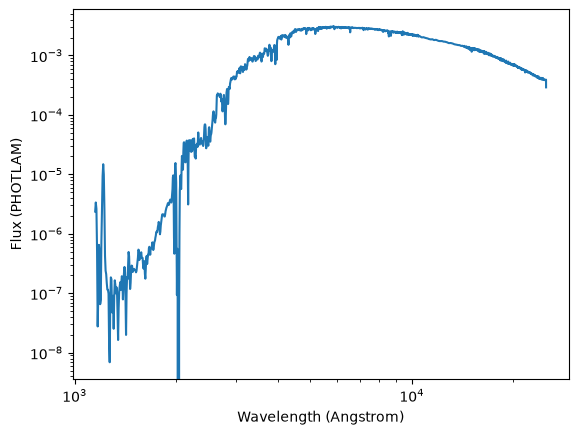

In [4]:
# HWO science case is targeting V of ~10 - 17.5, which is FUV of 23 to 30.5!!!
my_source.set_sed(name,25,0,0,'galex,fuv')
my_source.sed.plot()
plt.yscale('log')
plt.xscale('log')


## 3.0  Obtain and load an external source into the existing templates.  

In this sub-example, we will acquire data from the Hubble Spectroscopic Legacy Archive to obtain a high-resolution spectrum of a metal-poor star observed by HST.

See the HSLA Notebook here: https://spacetelescope.github.io/hst_notebooks/notebooks/HSLA/Intro/Intro.html#hsla_download


In [5]:
import os
from astroquery.mast import Observations
import shutil
from pathlib import Path

In [6]:
# Create and define the default path for storing files
outdir = './hsla_default_products'
if not os.path.exists(outdir):
    os.makedirs(outdir)
output = Path(outdir)

In [47]:
target = 'CD-52 112'  # This star was observed in HST program ID 17166.. Get from HSLA
#target = 'SZ 45'  # From ULLYSES.  Why was this NOT in HSLA?
# Conduct the query
obs = Observations.get_product_list(
     Observations.query_criteria(
        provenance_name='hsla',
        target_name=target
    )
)

In [53]:
# Look at the list of available products
obs[obs['productType'] == 'SCIENCE']   # this is the preview level, which abuts everything from uv to optical.
#obs[obs['description'] == 'FITS'][0]   # this is the preview level, which abuts everything from uv to optical.

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str3,str8,str23,str87,str1,str81,str9,str28,str5,str1,str4,str14,str5,str40,int64,str9,str6,int64,str5
349727485,HST,spectrum,hst_hsla_cd-52112--6441,HSLA coadded and abutted spectrum for multiple gratings,S,mast:HST/product/hsla/hst_cd-52112--6441/hst_cd-52112--6441_aspec.fits,SCIENCE,Minimum Recommended Products,ASPEC,--,HSLA,HSLA Cal 1.2.5,17166,hst_cd-52112--6441_aspec.fits,587520,349727485,PUBLIC,3,E230H
349727485,HST,spectrum,hst_hsla_cd-52112--6441,HSLA coadded spectrum for a singular grating and/or COS lifetime position,S,mast:HST/product/hsla/hst_cd-52112--6441/hst_stis_cd-52112--6441_e230h_cspec.fits,SCIENCE,Minimum Recommended Products,CSPEC,--,HSLA,HSLA Cal 1.2.5,17166,hst_stis_cd-52112--6441_e230h_cspec.fits,587520,349727485,PUBLIC,3,E230H


In [54]:
# We want the first option from the table above
res_table = Observations.download_products(
    obs[obs['productType'] == 'SCIENCE'][0],
#    obs[obs['description'] == 'FITS'][0],
    download_dir=str(output)
)
res_table

INFO:astroquery:Found cached file hsla_default_products/mastDownload/HST/hst_hsla_cd-52112--6441/hst_cd-52112--6441_aspec.fits with expected size 587520.


INFO: Found cached file hsla_default_products/mastDownload/HST/hst_hsla_cd-52112--6441/hst_cd-52112--6441_aspec.fits with expected size 587520. [astroquery.query]


Local Path,Status,Message,URL
str92,str8,object,object
hsla_default_products/mastDownload/HST/hst_hsla_cd-52112--6441/hst_cd-52112--6441_aspec.fits,COMPLETE,None,None


## 3.1 Inspect the downloaded spectrum
In this particular case, when looking at the metadata file, the aspec and cspec files are the same becaue there is a single STIS echelle dataset. However, the HSLA spectrum is still preferred over the standard MAST spectrum because the spectral orders are intercombined to form a single 1-D spectrum

In [55]:
res_table['Local Path'][0]

np.str_('hsla_default_products/mastDownload/HST/hst_hsla_cd-52112--6441/hst_cd-52112--6441_aspec.fits')

In [56]:
#outfile = outdir+'/mastDownload/HST/hst_hsla_cd-52112--6441/hst_stis_cd-52112--6441_e230h_cspec.fits'
hsla_data = fits.getdata(res_table['Local Path'][0])[0]


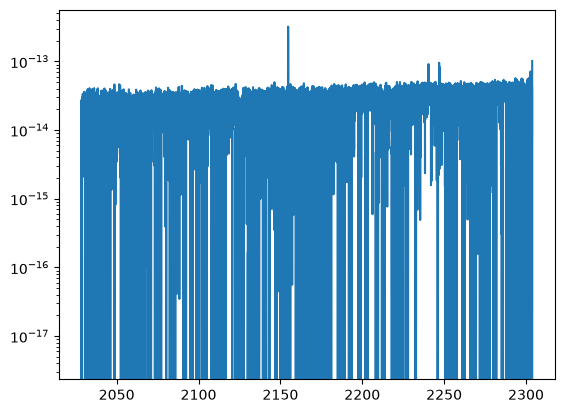

In [57]:
plt.plot(hsla_data['WAVELENGTH'], hsla_data['FLUX'])
plt.yscale('log')

## 3.2 Add user spectrum as a new possible template.

In [58]:
my_spectrum = synphot.spectrum.SourceSpectrum(synphot.models.Empirical1D, points= hsla_data['WAVELENGTH'], 
                                              lookup_table= hsla_data['FLUX']*synphot.units.FLAM,keep_neg=False)

syn_spectra_library[target] = my_spectrum


  points: [2028.3768 2028.3966 2028.5055 2028.5353 2030.6351 2030.6648 2030.6747
 2030.6846 2030.6946 2030.8431 2031.2491 2031.4275 2031.6355 2031.6553
 2031.883  2032.6953 2032.735  2032.9628 2033.3689 2033.3887 2033.4877
 2033.5273 2033.9136 2034.7754 2034.8248 2034.8447 2034.8744 2034.8942
 2034.9536 2035.2211 2035.6965 2035.7064 2035.7163 2035.9045 2035.9342
 2035.954  2036.063  2036.5087 2036.5385 2037.3209 2037.935  2037.945
 2038.0736 2038.0836 2038.4698 2039.2622 2039.2722 2039.6089 2040.0942
 2040.7183 2041.3324 2041.4017 2041.4116 2041.4215 2041.689  2042.1545
 2042.1644 2042.1842 2042.1941 2042.2239 2042.2338 2042.9667 2043.0657
 2043.5214 2044.809  2045.2646 2046.1066 2046.1165 2048.5034 2048.8105
 2048.8206 2052.525  2053.555  2053.5947 2055.1992 2056.0312 2056.3086
 2056.3284 2056.992  2057.0515 2057.101  2057.1802 2058.8245 2058.8442
 2058.8542 2058.8838 2059.3494 2059.5376 2059.5674 2059.5872 2059.607
 2059.6167 2059.6267 2059.6367 2059.6663 2059.686  2059.696  2059.725

In [70]:
#The new spectrum is now selectable as an option in the "my_source" object
my_source.list_templates()

dict_keys(['Classical T-Tauri Star', 'M1 Dwarf', 'M Dwarf', 'G Dwarf', 'O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)', 'O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)', 'O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)', 'O5V Star', 'G2V Star', 'B5V Star', 'M2V Star', 'G191B2B (WD)', 'GD71 (WD)', 'GD153 (WD)', '10 Myr Starburst', 'QSO', 'Seyfert 1', 'Seyfert 2', 'Liner', 'Orion Nebula', 'Starburst, No Dust', 'Starburst, E(B-V) = 0.6', 'Elliptical Galaxy', 'Sbc Galaxy', 'NGC 1068', 'Galaxy with f_esc, HI=1, HeI=1', 'Galaxy with f_esc, HI=0.001, HeI=1', 'Flat (AB)', 'Flat in F_lambda', 'Blackbody (5000K)', 'Blackbody (100,000K)', 'SZ 45', 'CD-52 112'])


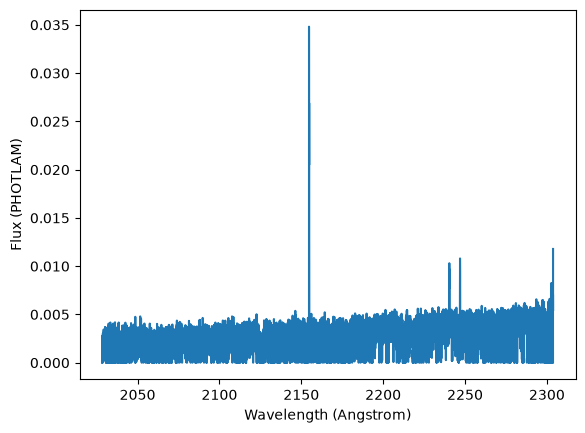

In [71]:
my_spectrum.plot()

In [73]:
type(my_source)

syotools.models.source.Source

In [63]:
my_source.set_sed(target,25,0,0,bandpass='galex,nuv')
my_source.sed.plot()
plt.xscale('log')
plt.title(target)


PartialOverlap: Spectrum and renormalization band do not fully overlap. You may use force=True to force the renormalization to proceed.

In [16]:
Source().list_templates()

dict_keys(['Classical T-Tauri Star', 'M1 Dwarf', 'M Dwarf', 'G Dwarf', 'O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)', 'O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)', 'O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)', 'O5V Star', 'G2V Star', 'B5V Star', 'M2V Star', 'G191B2B (WD)', 'GD71 (WD)', 'GD153 (WD)', '10 Myr Starburst', 'QSO', 'Seyfert 1', 'Seyfert 2', 'Liner', 'Orion Nebula', 'Starburst, No Dust', 'Starburst, E(B-V) = 0.6', 'Elliptical Galaxy', 'Sbc Galaxy', 'NGC 1068', 'Galaxy with f_esc, HI=1, HeI=1', 'Galaxy with f_esc, HI=0.001, HeI=1', 'Flat (AB)', 'Flat in F_lambda', 'Blackbody (5000K)', 'Blackbody (100,000K)', 'SZ 45'])


In [17]:
# For now let's continue with the G dwarf star
# Science case here: https://arxiv.org/pdf/2507.03180

# Figure 2 of https://arxiv.org/html/1105.1377v1#A2.F1  
#   FGK stars as B-V of ~0.3 to 0.6. G5 is ~0.7
#   FUV-V of inactive stars  is ~ 10.5 for B-V of 0.5 (F8 star) or 13 for B-V of 0.7

# HWO science case is targeting V of ~10 - 17.5, which is FUV of 23 to 30.5!!!

In [18]:
# Let's define some science cases from Table 3
goal_SNR = 40.
v_mags = np.array([10,12,14,17])
associ_impact = ['state-of-the-art','incremental', 'substantial', 'major progress']
key_waves = np.array([1586,1875,2020,2185,2282,3039])  # roughly every fifth line in Table 1

## 4.0 Define the observation 
1. Instantiate the HWO telescope object and load the paramters from EAC5
2. Find and load the appropriate instrument configuration. For this case, we want the FUV_PSS.Echelle, which is the only high spectral resolution channel currently being modeled
3. Define an exposure. For this example, we'll set the desired S/N and request the needed exposure time.

In [19]:
#Instantiate the observatory using syotools.models.Telescope
hwo_ex1 = Telescope()
hwo_ex1.set_from_hwome('EAC5') 

## 4.1 Look at options
In some cases, you know exactly what instrument/setting you want to experiement with, but the following code shows some ways to see what is available for experimentation.

In [20]:
# List out the available instruments
for k in hwo_ex1.instruments.keys():
    print(k)

High Resolution Astrometry.HRI_A_VIS_Imager
HRI_S.HRI_S_NIR_Imager
HRI_S.HRI_S_NIR_Spectrograph
HRI_S.HRI_S_UVIS_Imager
HRI_S.HRI_S_UVIS_Spectrograph
UV_IFU.UV_IFU_Group1_IFS
UV_IFU.UV_IFU_Group2_IFS
UV_IFU.UV_IFU_Group3_IFS
UV_IFU.UV_IFU_Group4_IFS
UV_MOS.FUV_PSS_Spectrograph
UV_MOS.FUV_IMG_Imager
UV_MOS.FUV_MOS_MOS
UV_MOS.FUV_MOS_L_MOS
UV_MOS.NUV_MOS_MOS


In [21]:
# Once you select an instrument, you can then see what channels, or "bands"  are available
my_instru = hwo_ex1.instruments['UV_MOS.FUV_PSS_Spectrograph']
print(my_instru.n_bands)
print(my_instru.bandnames)

1
['FUV_PSS.Echelle']


In [22]:
# You can then access information about that particular mode under the configuration['band'] dictionary, using the mode as a key
obs_mode = my_instru.configuration['band'][my_instru.bandnames[0]]

In [23]:
obs_mode.keys()

dict_keys(['internal_name', 'bandpass', 'original_wave', 'original_thru', 'effective_wavelength', 'wave_min', 'bandwidth', 'wave_max', 'optics', 'resolution', 'kind'])

In [24]:
obs_mode['resolution']

[57143.0, 114286.0]

In [39]:
# This highest resolution mode is still being developed, so lets find a differet mode with high resolution
ins_choices = ['UV_MOS.FUV_MOS_MOS','UV_MOS.NUV_MOS_MOS']

# We'll loop through the different instruments and print out the band options, with highest and lowest wavebin and spectral resolution
for choice in ins_choices:
    my_instru = hwo_ex1.instruments[choice]
    print(f'\n Options for {choice} instrument')
    for one_band in my_instru.bandnames:
        band_info = my_instru.configuration['band'][one_band]
        print('  {}  R={:.0f} l={:.0f}-{:.0f}'.format(one_band, band_info['resolution'],\
                                                      band_info['wave_min'].value,band_info['wave_max']))



 Options for UV_MOS.FUV_MOS_MOS instrument
  FUV_MOS.G120M  R=30000 l=1094-1540 Angstrom
  FUV_MOS.G150M  R=30000 l=1149-1818 Angstrom
  FUV_MOS.G180M  R=30000 l=1434-2171 Angstrom

 Options for UV_MOS.NUV_MOS_MOS instrument
  NUV_MOS.G300M  R=20000 l=2152-4275 Angstrom
  NUV_MOS.G650LL  R=500 l=3939-8715 Angstrom
  NUV_MOS.G700L  R=15000 l=4121-9301 Angstrom


## 4.2  Make the instrument and band selections
Now that we have seen what some of the options are, we can select a configuration to use for creating the exposures.

In [41]:
# Edit these two options to select the instrument and band to work with
ins_choice = 'UV_MOS.FUV_PSS_Spectrograph'
band_choice =  'FUV_PSS.Echelle'

In [100]:
ins = hwo_ex1.instruments[ins_choice]
resolution = ins.configuration['band'][band_choice]['resolution']  # for plot label purposes
ins.band=band_choice

/Users/jcarlberg/miniconda3/envs/hwotools/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jcarlberg/miniconda3/envs/hwotools/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jcarlberg/miniconda3/envs/hwotools/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jcarlberg/miniconda3/envs/hwotools/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 1.0, 'G2V Star: FUV_PSS.Echelle, R=[57143.0, 114286.0]')

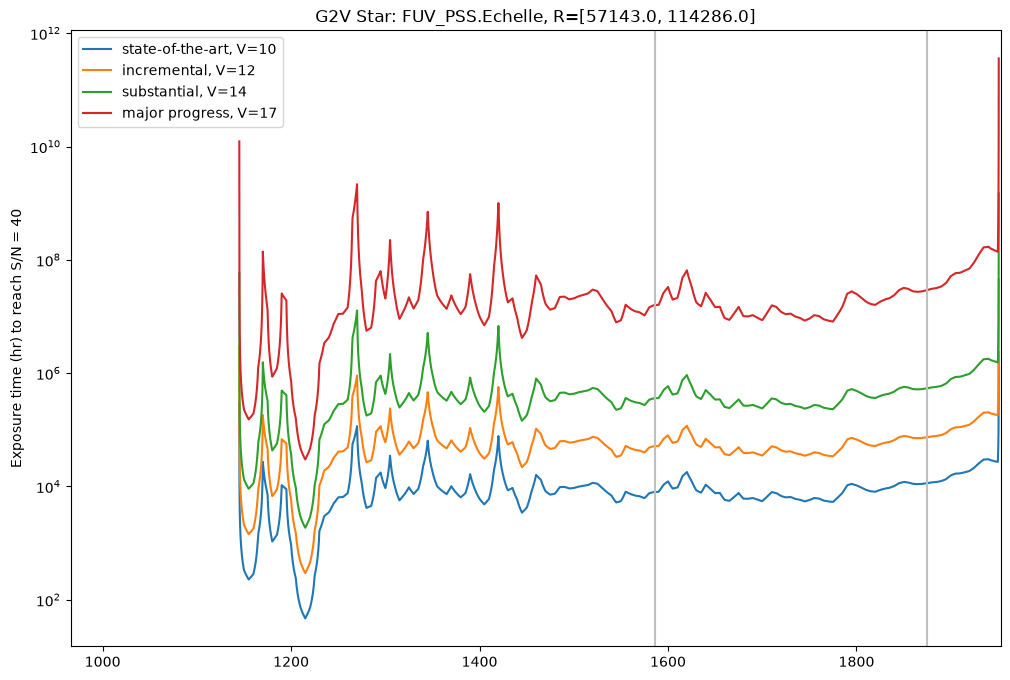

In [107]:
# Choose the units you want to plot
t_unit='hr'
#t_unit='s'

# Choose the object you want to use
name = 'G2V Star'

#Choose the goal SNR
goal_snr = 40

f=plt.figure(figsize=(12,8))
for v, impact in zip (v_mags, associ_impact):
    my_source.set_sed(name,v,0,0,'johnson,v',)

    # Create and add the exposure
    exposure = ins.create_exposure(source = my_source)
    exposure.instrument.band = band_choice  #I can't verify this is doing what I want!
    exposure.snr = goal_snr
    exposure.unknown = "exptime"
    exp_time  = exposure.recover('exptime')
    plt.plot(exposure.wave[0],exp_time[0].to(t_unit),label=f'{impact}, V={v}')
plt.legend()
plt.yscale('log')
plt.ylabel(f'Exposure time ({t_unit}) to reach S/N = 40')

for a_wave in key_waves:
    plt.axvline(a_wave,color='silver')
plt.xlim(np.min(exposure.wave),np.max(exposure.wave))
plt.title(f'{my_source.name}: {band_choice}, R={resolution}')

Text(0.5, 1.0, 'G2V Star: FUV_PSS.Echelle, R=[57143.0, 114286.0]')

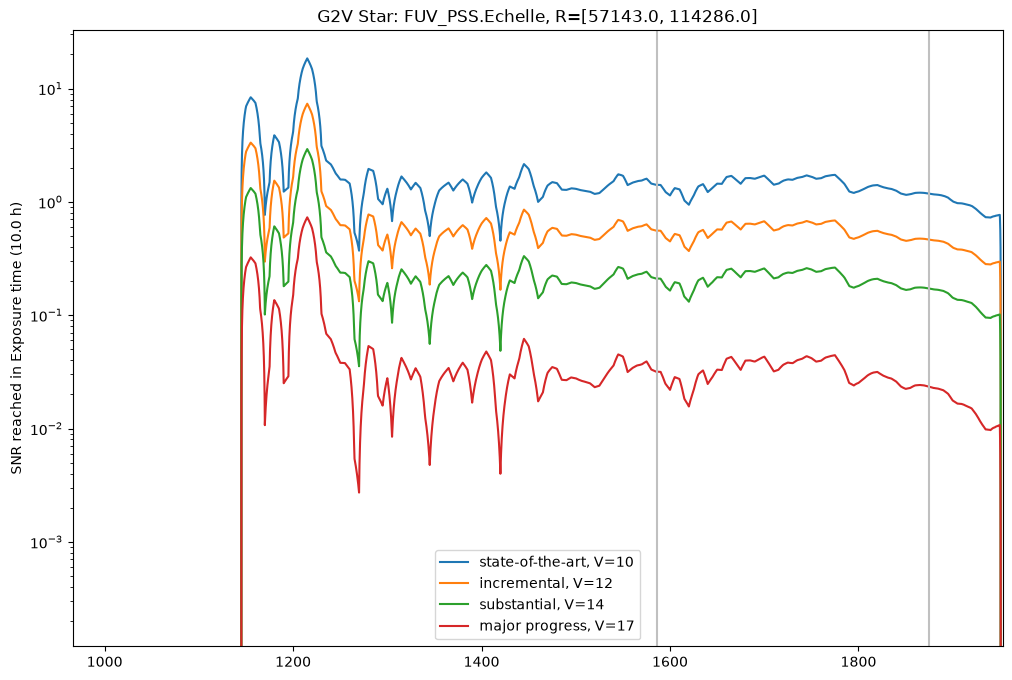

In [108]:
# reverse the problem, and see what the S/N is obtained in 10 hours of observation!
goal_exptime= 10*u.hr

f=plt.figure(figsize=(12,8))
for v, impact in zip (v_mags, associ_impact):
    my_source.set_sed(name,v,0,0,'johnson,v',)

    # Create and add the exposure
    exposure = ins.create_exposure(source=my_source)
    exposure.instrument.band = band_choice
    exposure.exptime = goal_exptime
    exposure.unknown = "snr"
    snr  = exposure.recover('snr')
    plt.plot(exposure.wave[0],snr[0],label=f'{impact}, V={v}')
plt.legend()
plt.yscale('log')
plt.ylabel(f'SNR reached in Exposure time ({goal_exptime})')

for a_wave in key_waves:
    plt.axvline(a_wave,color='silver')
plt.xlim(np.min(exposure.wave),np.max(exposure.wave))
plt.title(f'{my_source.name}: {band_choice}, R={resolution}')

In [87]:
help(ins.create_exposure)

Help on method create_exposure in module syotools.models.spectrograph:

create_exposure(source=None) method of syotools.models.spectrograph.Spectrograph instance



In [290]:
!export PYSYN_CDBS='/grp/redcat/trds'

In [91]:
help(exposure.instrument)

Help on Spectrograph in module syotools.models.spectrograph object:

class Spectrograph(syotools.models.instrument.Instrument)
 |  Spectrograph(
 |      telescope,
 |      default_model=OrderedDict({'_lumos_default_file': '/Users/jcarlberg/miniconda3/envs/hwotools/lib/python3.13/site-packages/syotools/defaults/../reference_data/LUMOS_ETC.fits', 'name': 'UVI', 'modes': ['G120M', 'G150M', 'G180M', 'G155L', 'G145LL', 'G300M'], 'descriptions': OrderedDict({'G120M': 'G120M (R = 30,400)', 'G150M': 'G150M (R = 37,800)', 'G180M': 'G180M (R = 40,800)', 'G155L': 'G155L (R = 11,600)', 'G145LL': 'G145LL (R = 500)', 'G300M': 'G300M (R = 28,000)'}), 'bef': [0.0, 'cm-2 erg Angstrom-1 s-1'], 'R': [10.0, 'pix'], 'wrange': [[100.0, 10000.0], 'Angstrom'], 'wave': [0.0, 'Angstrom'], 'aeff': [0.0, 'cm2'], 'mode': 'G150M'}),
 |      **kw
 |  )
 |
 |  The basic spectrograph class, which provides parameter storage for
 |  optimization.
 |
 |  Attributes: #adapted from the original in Telescope.py
 |      tele